# Assignment 4 - ECON7890
## Hong Kong Kowloon Property Market Analysis (2014-2020)

**Data Period**: November 2014 - November 2020

---

### Data Sources

#### 1. Primary Data - Property Transactions
| Item | Description |
|------|-------------|
| **File** | hw.csv |
| **Source** | 28HSE Property Data (https://data.28hse.com/en/) |
| **Content** | Land Registry transaction records for Kowloon district |
| **Records** | ~80,000 property transactions |
| **Period** | November 2014 - November 2020 |

#### 2. External Data - Macroeconomic Indicators
| Indicator | Source | URL |
|-----------|--------|-----|
| **Hang Seng Index (HSI)** | Yahoo Finance | https://finance.yahoo.com/quote/%5EHSI/ |
| **Unemployment Rate** | HK Census and Statistics Department | https://www.censtatd.gov.hk/ |
| **Best Lending Rate (BLR)** | Hong Kong Monetary Authority (HKMA) | https://www.hkma.gov.hk/ |

**External Data File**: macro_data_real.csv

---

### Table of Contents
1. **Question 1**: Import and Cleaning Data (15%)
2. **Question 2**: Merge Data (15%)
3. **Question 3**: Exploratory Data Analysis (25%)
4. **Question 4**: Learning Model (35%)
5. **Question 5**: Findings and Conclusion (10%)


## Question 1: Import and Cleaning Data (15%)

### Tasks:
- Import the data to a pandas DataFrame from the data file
- Clean up the data
- Check and handle missing values
- Rename columns to more meaningful names


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")


Libraries imported successfully!


### 1.1 Load Raw Data


In [ ]:
# Load raw data
try:
    df_raw = pd.read_csv('hw.csv', encoding='utf-8')
    print("Data loaded successfully (UTF-8 encoding)")
except:
    try:
        df_raw = pd.read_csv('hw.csv', encoding='gb18030')
        print("Data loaded successfully (GB18030 encoding)")
    except Exception as e:
        print(f"Error loading data: {e}")

print(f"\nDataset Shape: {df_raw.shape}")
print(f"Total Records: {len(df_raw):,}")
print(f"Total Columns: {len(df_raw.columns)}")

# Display column names
print("\nOriginal Column Names:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {col}")


Data loaded successfully (UTF-8 encoding)

Dataset Shape: (80000, 35)
Total Records: 80,000
Total Columns: 35

Original Column Names:
   1. date
   2. withpre
   3. id
   4. rootid
   5. fatherid
   6. catid
   7. catname
   8. catfathername
   9. url_father
  10. url_cat
  11. source
  12. contract
  13. memo
  14. price
  15. price_value
  16. holddate
  17. winloss_flag
  18. winloss
  19. act_area
  20. area
  21. arearaw
  22. sq_price
  23. sq_price_value
  24. sq_actprice
  25. sq_actprice_value
  26. month
  27. day
  28. date_dm
  29. date_y
  30. block
  31. state
  32. floor
  33. room
  34. addr
  35. Unnamed: 34


In [ ]:
# Display first few rows
print("First 5 rows of raw data:")
df_raw.head()


First 5 rows of raw data:


,date,withpre,id,rootid,fatherid,catid,catname,catfathername,url_father,url_cat,source,contract,memo,price,price_value,holddate,winloss_flag,winloss,act_area,area,arearaw,sq_price,sq_price_value,sq_actprice,sq_actprice_value,month,day,date_dm,date_y,block,state,floor,room,addr,Unnamed: 34
0,2020-11-27,1.00,683333,2,79,2058,Bel Air Heights,Diamond Hill,https://data.28hse.com/en/kl/diamond-hill,https://data.28hse.com/en/kl/diamond-hill/2058...,Land Registry,Agreement,20112702480015,$10M,10000000,16 years 251 days,1,413%,657ft<sup>2</sup>,826ft<sup>2</sup>,826.00,$12107,12106.54,$15221,15220.70,Nov,27,27/11,2020,BLOCK 2,NaN,2#,E,BLOCK 2 2#/F Room E,NaN
1,2020-11-27,1.00,683332,2,71,2712,Fa Yuen Plaza,Mong Kok,https://data.28hse.com/en/kl/mong-kok,https://data.28hse.com/en/kl/mong-kok/2712_fa-...,Land Registry,Agreement,20112702470044,$4.28M,4280000,2 years 350 days,1,22%,214ft<sup>2</sup>,347ft<sup>2</sup>,347.00,$12334,12334.29,$20000,20000.00,Nov,27,27/11,2020,NaN,NaN,1#,C,1#/F Room C,NaN
2,2020-11-27,1.00,683331,2,78,3094,Caldecott Hill,Yau Yat Tsuen,https://data.28hse.com/en/kl/yau-yat-tsuen,https://data.28hse.com/en/kl/yau-yat-tsuen/309...,Land Registry,Agreement,20112702440018,$11M,11000000,5 years 219 days,0,14%,991ft<sup>2</sup>,1282ft<sup>2</sup>,1282.00,$8580,8580.34,$11100,11099.90,Nov,27,27/11,2020,TOWER 1,NaN,7,E,TOWER 1 7/F Room E,NaN
3,2020-11-27,NaN,683330,2,57,5035,Pang Ching Court,Wong Tai Sin,https://data.28hse.com/en/kl/wong-tai-sin,https://data.28hse.com/en/kl/wong-tai-sin/5035...,Land Registry,Agreement,20112702410017,$4.9M,4900000,--,-1,--,--,583ft<sup>2</sup>,583.00,$8405,8404.80,--,0.00,Nov,27,27/11,2020,NaN,NaN,1#,22,1#/F Room 22,NaN
4,2020-11-27,1.00,683329,2,67,2564,Metro Harbour View,Tai Kok Tsui,https://data.28hse.com/en/kl/tai-kok-tsui,https://data.28hse.com/en/kl/tai-kok-tsui/2564...,Land Registry,Agreement,20112702400032,$7.15M,7150000,12 years 157 days,1,198%,412ft<sup>2</sup>,595ft<sup>2</sup>,595.00,$12017,12016.81,$17354,17354.37,Nov,27,27/11,2020,BLOCK 8,NaN,1#,B,BLOCK 8 1#/F Room B,NaN


### 1.2 Data Cleaning and Column Renaming


In [ ]:
# Select and rename important columns
df = df_raw.copy()

# Column mapping (old name -> new name)
column_mapping = {
    'date': 'transaction_date',
    'catfathername': 'district',
    'catname': 'estate_name',
    'price_value': 'price_hkd',
    'area': 'saleable_area_sqft',
    'act_area': 'actual_area_sqft',
    'floor': 'floor',
    'room': 'room_number',
    'block': 'block_name',
    'sq_price_value': 'price_per_sqft',
    'sq_actprice_value': 'price_per_actual_sqft',
    'holddate': 'holding_period',
    'winloss': 'profit_loss',
    'winloss_flag': 'profit_loss_flag',
    'addr': 'addr',
    'contract': 'contract',
    'memo': 'memo',
    'date_y': 'year',
    'month': 'month'
}

# Rename columns
df = df.rename(columns=column_mapping)

# Select columns we need
columns_to_keep = list(column_mapping.values())
columns_to_keep = [c for c in columns_to_keep if c in df.columns]
df = df[columns_to_keep]

print(f"Columns after renaming: {len(df.columns)}")
print(df.columns.tolist())


Columns after renaming: 19
['transaction_date', 'district', 'estate_name', 'price_hkd', 'saleable_area_sqft', 'actual_area_sqft', 'floor', 'room_number', 'block_name', 'price_per_sqft', 'price_per_actual_sqft', 'holding_period', 'profit_loss', 'profit_loss_flag', 'addr', 'contract', 'memo', 'year', 'month']


In [ ]:
# Clean area columns - remove HTML tags like <sup>2</sup>
def clean_area(value):
    if pd.isna(value):
        return np.nan
    value = str(value)
    # Remove HTML tags
    value = re.sub(r'<[^>]+>', '', value)
    # Remove non-numeric characters except decimal point
    value = re.sub(r'[^\d.]', '', value)
    try:
        return float(value)
    except:
        return np.nan

# Clean area columns
for col in ['saleable_area_sqft', 'actual_area_sqft']:
    if col in df.columns:
        df[col] = df[col].apply(clean_area)

# Convert date column
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

# Create year_month column for merging with macro data
df['year_month'] = df['transaction_date'].dt.to_period('M').astype(str)

# Convert year to numeric
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# Convert month to numeric
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
df['month'] = df['month'].map(month_map)

print("Data types after cleaning:")
print(df.dtypes)


Data types after cleaning:
transaction_date         datetime64[ns]
district                         object
estate_name                      object
price_hkd                         int64
saleable_area_sqft              float64
actual_area_sqft                float64
floor                            object
room_number                      object
block_name                       object
price_per_sqft                  float64
price_per_actual_sqft           float64
holding_period                   object
profit_loss                      object
profit_loss_flag                  int64
addr                             object
contract                         object
memo                              int64
year                              int64
month                             int64
year_month                       object
dtype: object


### 1.3 Handle Missing Values


In [ ]:
# Check missing values
print("Missing Values Summary:")
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])

# Fill or handle missing values
# For numerical columns, we keep NaN (will be handled in modeling)
# For categorical columns, fill with 'Unknown'
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna('Unknown')

print(f"\nCleaned dataset shape: {df.shape}")


Missing Values Summary:
                    Missing Count  Missing %
saleable_area_sqft          30508      38.14
actual_area_sqft            41743      52.18
floor                          32       0.04
room_number                   258       0.32
block_name                  32308      40.38

Cleaned dataset shape: (80000, 20)


In [ ]:
# Question 1 Summary - Display cleaned data
print("="*60)
print("Question 1 Summary: Data Import and Cleaning")
print("="*60)
print(f"\nTotal Records: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")
print(f"Date Range: {df['year_month'].min()} to {df['year_month'].max()}")
print(f"Number of Districts: {df['district'].nunique()}")
print(f"Number of Estates: {df['estate_name'].nunique()}")

print("\nNumerical Summary:")
df.describe()


Question 1 Summary: Data Import and Cleaning

Total Records: 80,000
Total Columns: 20
Date Range: 2014-10 to 2020-11
Number of Districts: 32
Number of Estates: 2009

Numerical Summary:


,transaction_date,price_hkd,saleable_area_sqft,actual_area_sqft,price_per_sqft,price_per_actual_sqft,profit_loss_flag,memo,year,month
count,80000,80000.00,49492.00,38257.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00
mean,2017-09-10 04:46:34.680000256,7581254.10,6889.85,5376.79,6672.02,7721.44,0.34,17257435716350.75,2017.19,6.54
min,2014-10-27 00:00:00,50000.00,1052.00,1522.00,0.00,0.00,-1.00,14102700270062.00,2014.00,1.00
25%,2016-04-20 00:00:00,3916735.00,4832.00,3722.00,0.00,0.00,-1.00,16042001967528.00,2016.00,4.00
50%,2017-08-09 12:00:00,5550000.00,6252.00,4962.00,8000.00,0.00,1.00,17080951345015.50,2017.00,6.00
75%,2019-02-28 00:00:00,8280000.00,7792.00,6122.00,11205.72,15387.05,1.00,19022800470139.75,2019.00,10.00
max,2020-11-27 00:00:00,423800000.00,75212.00,44142.00,79324.59,104418.10,1.00,20112702480015.00,2020.00,12.00
std,NaN,8657834.62,3267.48,2759.87,6140.29,8919.34,0.93,1758010689282.84,1.76,3.40


---
## Question 2: Merge Data (15%)

### Tasks:
- Get external dataset (unemployment rate, HSI, BLR)
- Merge macroeconomic data with property transaction data


### 2.1 Load External Macroeconomic Data

#### Data Sources for Question 2:

| Indicator | Source | Description |
|-----------|--------|-------------|
| **Hang Seng Index (HSI)** | Yahoo Finance (^HSI) | Monthly closing price, downloaded via `yfinance` Python library |
| **Unemployment Rate** | HK Census and Statistics Department | Quarterly data from official government statistics, interpolated to monthly |
| **Best Lending Rate (BLR)** | Hong Kong Monetary Authority (HKMA) | Prime lending rate from major banks in Hong Kong |

**Data File**: `macro_data_real.csv` (73 monthly records from 2014-11 to 2020-11)


In [ ]:
# Load macroeconomic data
try:
    df_macro = pd.read_csv('macro_data_real.csv')
    print("Macroeconomic data loaded successfully!")
    print(f"\nMacro data shape: {df_macro.shape}")
    print(f"Date range: {df_macro['year_month'].min()} to {df_macro['year_month'].max()}")
    print("\nMacro data columns:")
    print(df_macro.columns.tolist())
    df_macro.head(10)
except FileNotFoundError:
    print("Note: macro_data_real.csv not found. Run create_real_macro_data.py first.")


Macroeconomic data loaded successfully!

Macro data shape: (73, 5)
Date range: 2014-11 to 2020-11

Macro data columns:
['year_month', 'unemployment_rate', 'hsi_close', 'hsi_volume', 'blr']


### 2.2 Merge Property Data with Macro Data


In [ ]:
# Merge datasets on year_month
print(f"Before merge - Property records: {len(df):,}")
print(f"Before merge - Macro records: {len(df_macro)}")

df_merged = pd.merge(df, df_macro, on='year_month', how='left')

print(f"\nAfter merge - Total records: {len(df_merged):,}")
print(f"New columns added: {[c for c in df_merged.columns if c in df_macro.columns and c != 'year_month']}")

# Check merge success
unmatched = df_merged['unemployment_rate'].isna().sum()
print(f"\nUnmatched records: {unmatched:,} ({unmatched/len(df_merged)*100:.1f}%)")

# Create additional features
monthly_count = df_merged.groupby('year_month').size().reset_index(name='monthly_transactions')
df_merged = pd.merge(df_merged, monthly_count, on='year_month', how='left')

monthly_avg = df_merged.groupby('year_month')['price_hkd'].mean().reset_index(name='monthly_avg_price')
df_merged = pd.merge(df_merged, monthly_avg, on='year_month', how='left')

print(f"\nFinal merged dataset: {df_merged.shape}")


Before merge - Property records: 80,000
Before merge - Macro records: 73

After merge - Total records: 80,000
New columns added: ['unemployment_rate', 'hsi_close', 'hsi_volume', 'blr']

Unmatched records: 268 (0.3%)

Final merged dataset: (80000, 26)


In [ ]:
# Question 2 Summary
print("="*60)
print("Question 2 Summary: Data Merge")
print("="*60)
print(f"\nMerged Dataset:")
print(f"  - Records: {len(df_merged):,}")
print(f"  - Columns: {len(df_merged.columns)}")
print(f"\nMacro Indicators Range:")
print(f"  - Unemployment: {df_merged['unemployment_rate'].min():.1f}% - {df_merged['unemployment_rate'].max():.1f}%")
print(f"  - HSI: {df_merged['hsi_close'].min():,.0f} - {df_merged['hsi_close'].max():,.0f}")
print(f"  - BLR: {df_merged['blr'].min():.3f}% - {df_merged['blr'].max():.3f}%")


Question 2 Summary: Data Merge

Merged Dataset:
  - Records: 80,000
  - Columns: 26

Macro Indicators Range:
  - Unemployment: 2.8% - 6.6%
  - HSI: 19,112 - 32,887
  - BLR: 5.000% - 5.125%


---
## Question 3: Exploratory Data Analysis (25%)

### Tasks:
- Do some exploratory data analysis
- Create visualizations to understand the data


### 3.1 Basic Statistics


In [ ]:
# Basic Statistics
print("="*60)
print("Numerical Variables Summary")
print("="*60)
numerical_cols = ['price_hkd', 'saleable_area_sqft', 'actual_area_sqft', 
                  'price_per_sqft', 'unemployment_rate', 'hsi_close', 'blr']
available_cols = [c for c in numerical_cols if c in df_merged.columns]
df_merged[available_cols].describe()


Numerical Variables Summary


,price_hkd,saleable_area_sqft,actual_area_sqft,price_per_sqft,unemployment_rate,hsi_close,blr
count,80000.00,49492.00,38257.00,80000.00,79732.00,79732.00,79732.00
mean,7581254.10,6889.85,5376.79,6672.02,3.45,25593.18,5.01
std,8657834.62,3267.48,2759.87,6140.29,0.99,3009.81,0.04
min,50000.00,1052.00,1522.00,0.00,2.80,19111.93,5.00
25%,3916735.00,4832.00,3722.00,0.00,2.90,23297.15,5.00
50%,5550000.00,6252.00,4962.00,8000.00,3.30,24979.69,5.00
75%,8280000.00,7792.00,6122.00,11205.72,3.30,27970.30,5.00
max,423800000.00,75212.00,44142.00,79324.59,6.60,32887.27,5.12


In [ ]:
# Monthly aggregation for time series analysis
monthly_stats = df_merged.groupby('year_month').agg({
    'price_hkd': ['mean', 'median', 'count'],
    'price_per_sqft': 'mean',
    'unemployment_rate': 'first',
    'hsi_close': 'first',
    'blr': 'first'
}).reset_index()
monthly_stats.columns = ['year_month', 'avg_price', 'median_price', 'transaction_count',
                         'avg_price_per_sqft', 'unemployment_rate', 'hsi_close', 'blr']

print(f"Monthly Statistics: {len(monthly_stats)} months")
print(f"Average monthly transactions: {monthly_stats['transaction_count'].mean():.0f}")
monthly_stats.head(10)


Monthly Statistics: 74 months
Average monthly transactions: 1081


,year_month,avg_price,median_price,transaction_count,avg_price_per_sqft,unemployment_rate,hsi_close,blr
0,2014-10,8543918.87,4669000.00,268,7830.44,NaN,NaN,NaN
1,2014-11,7122548.95,4380000.00,1089,6738.50,3.30,23987.45,5.00
2,2014-12,6174636.06,4660000.00,1525,5870.08,3.30,23605.04,5.00
3,2015-01,5993312.66,5050000.00,1698,5921.28,3.30,24507.05,5.00
4,2015-02,6068829.42,4620000.00,1269,6929.04,3.30,24823.29,5.00
5,2015-03,6618756.71,5170000.00,1156,5871.06,3.30,24900.89,5.00
6,2015-04,7228897.45,5138000.00,985,6354.69,3.30,28133.00,5.00
7,2015-05,6681988.01,5272444.00,1360,4618.27,3.30,27424.19,5.00
8,2015-06,6974219.48,4892625.00,1288,6715.80,3.30,26250.03,5.00
9,2015-07,7289524.27,5318100.00,1177,6747.61,3.30,24636.28,5.00


### 3.2 Visualizations


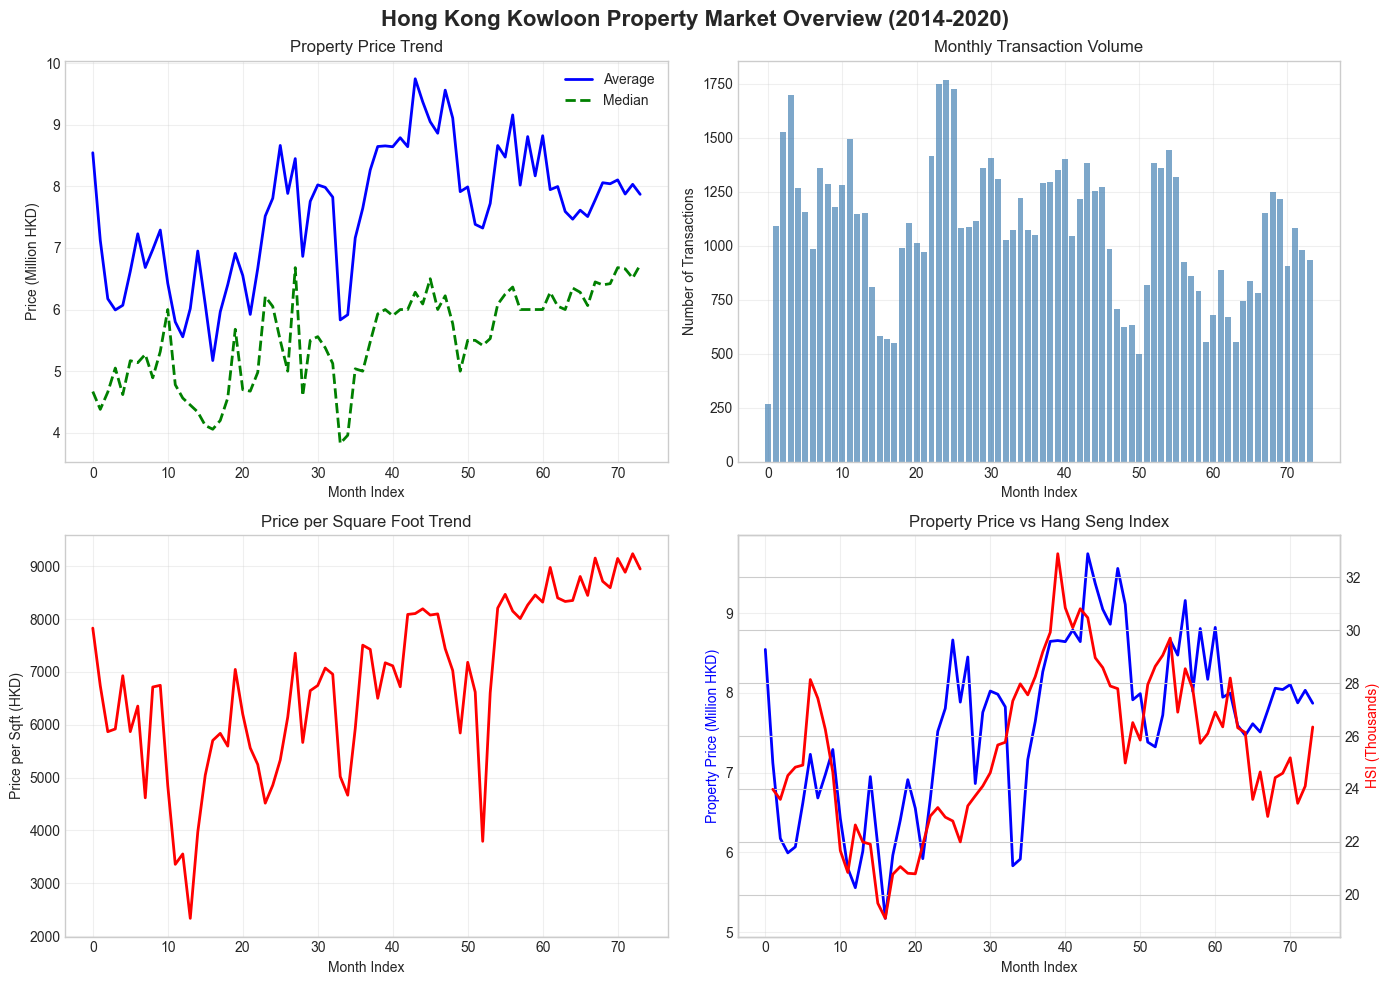

In [ ]:
# Figure 1: Market Overview
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hong Kong Kowloon Property Market Overview (2014-2020)', fontsize=16, fontweight='bold')

# 1.1 Price Trend
ax1 = axes[0, 0]
ax1.plot(range(len(monthly_stats)), monthly_stats['avg_price']/1e6, 'b-', linewidth=2, label='Average')
ax1.plot(range(len(monthly_stats)), monthly_stats['median_price']/1e6, 'g--', linewidth=2, label='Median')
ax1.set_xlabel('Month Index')
ax1.set_ylabel('Price (Million HKD)')
ax1.set_title('Property Price Trend')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 1.2 Transaction Volume
ax2 = axes[0, 1]
ax2.bar(range(len(monthly_stats)), monthly_stats['transaction_count'], color='steelblue', alpha=0.7)
ax2.set_xlabel('Month Index')
ax2.set_ylabel('Number of Transactions')
ax2.set_title('Monthly Transaction Volume')
ax2.grid(True, alpha=0.3)

# 1.3 Price per Sqft
ax3 = axes[1, 0]
ax3.plot(range(len(monthly_stats)), monthly_stats['avg_price_per_sqft'], 'r-', linewidth=2)
ax3.set_xlabel('Month Index')
ax3.set_ylabel('Price per Sqft (HKD)')
ax3.set_title('Price per Square Foot Trend')
ax3.grid(True, alpha=0.3)

# 1.4 HSI vs Property Price
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()
ax4.plot(range(len(monthly_stats)), monthly_stats['avg_price']/1e6, 'b-', linewidth=2, label='Property Price')
ax4_twin.plot(range(len(monthly_stats)), monthly_stats['hsi_close']/1000, 'r-', linewidth=2, label='HSI')
ax4.set_xlabel('Month Index')
ax4.set_ylabel('Property Price (Million HKD)', color='b')
ax4_twin.set_ylabel('HSI (Thousands)', color='r')
ax4.set_title('Property Price vs Hang Seng Index')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


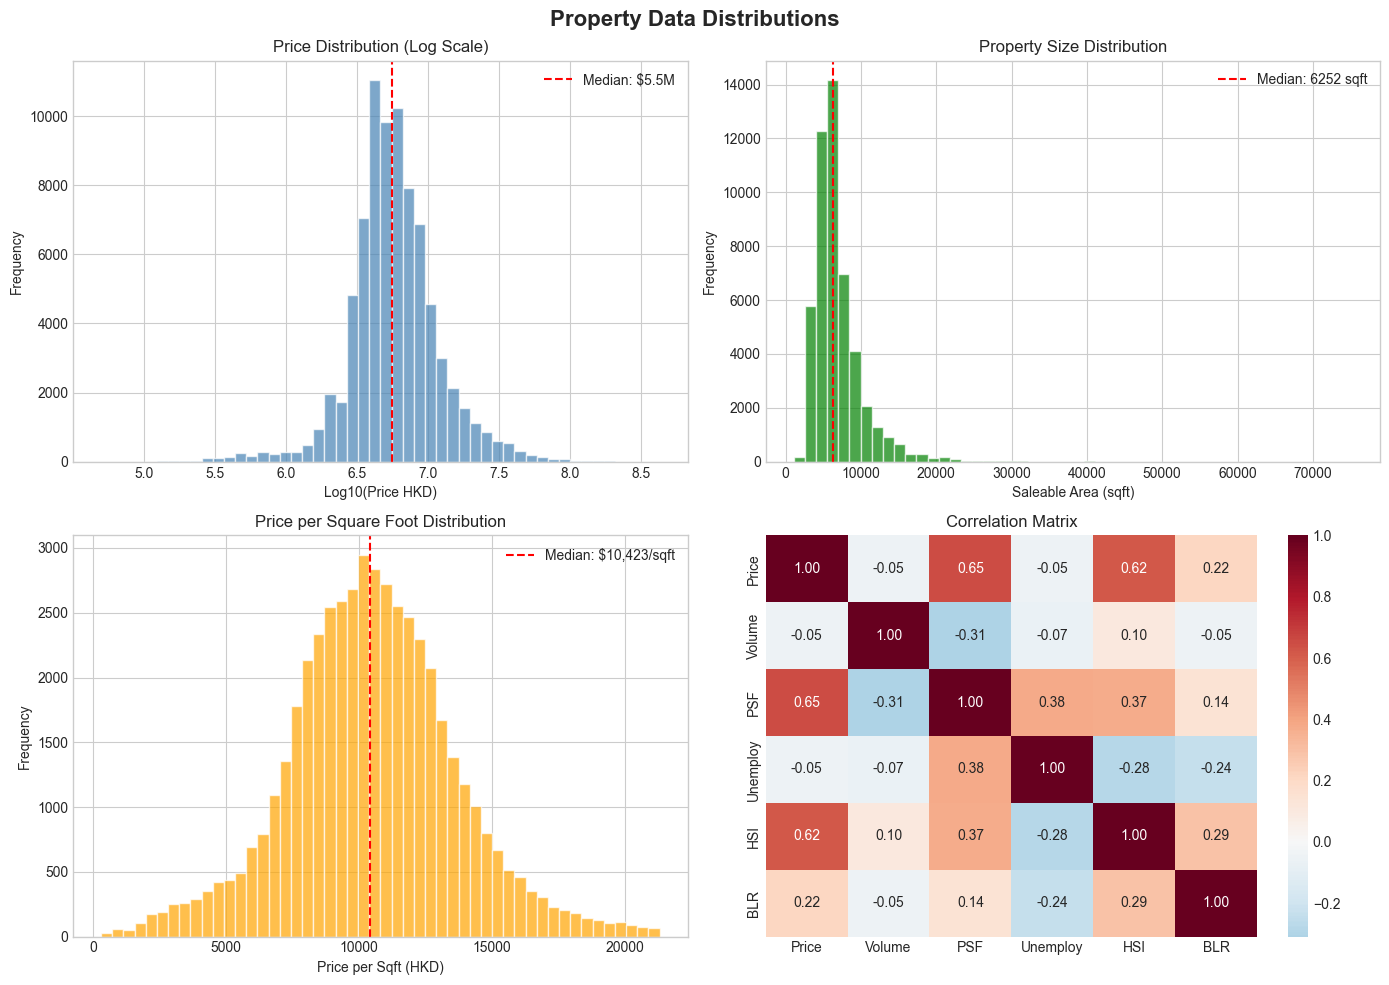

In [ ]:
# Figure 2: Distribution Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Property Data Distributions', fontsize=16, fontweight='bold')

# 2.1 Price Distribution
ax1 = axes[0, 0]
prices = df_merged['price_hkd'].dropna()
prices = prices[prices > 0]
ax1.hist(np.log10(prices), bins=50, color='steelblue', edgecolor='white', alpha=0.7)
ax1.set_xlabel('Log10(Price HKD)')
ax1.set_ylabel('Frequency')
ax1.set_title('Price Distribution (Log Scale)')
ax1.axvline(np.log10(prices.median()), color='red', linestyle='--', label=f'Median: ${prices.median()/1e6:.1f}M')
ax1.legend()

# 2.2 Area Distribution
ax2 = axes[0, 1]
areas = df_merged['saleable_area_sqft'].dropna()
areas = areas[areas > 0]
ax2.hist(areas, bins=50, color='green', edgecolor='white', alpha=0.7)
ax2.set_xlabel('Saleable Area (sqft)')
ax2.set_ylabel('Frequency')
ax2.set_title('Property Size Distribution')
ax2.axvline(areas.median(), color='red', linestyle='--', label=f'Median: {areas.median():.0f} sqft')
ax2.legend()

# 2.3 Price per Sqft Distribution
ax3 = axes[1, 0]
psf = df_merged['price_per_sqft'].dropna()
psf = psf[(psf > 0) & (psf < psf.quantile(0.99))]
ax3.hist(psf, bins=50, color='orange', edgecolor='white', alpha=0.7)
ax3.set_xlabel('Price per Sqft (HKD)')
ax3.set_ylabel('Frequency')
ax3.set_title('Price per Square Foot Distribution')
ax3.axvline(psf.median(), color='red', linestyle='--', label=f'Median: ${psf.median():,.0f}/sqft')
ax3.legend()

# 2.4 Correlation Heatmap
ax4 = axes[1, 1]
corr_cols = ['avg_price', 'transaction_count', 'avg_price_per_sqft', 'unemployment_rate', 'hsi_close', 'blr']
corr_matrix = monthly_stats[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            xticklabels=['Price', 'Volume', 'PSF', 'Unemploy', 'HSI', 'BLR'],
            yticklabels=['Price', 'Volume', 'PSF', 'Unemploy', 'HSI', 'BLR'], ax=ax4)
ax4.set_title('Correlation Matrix')

plt.tight_layout()
plt.show()


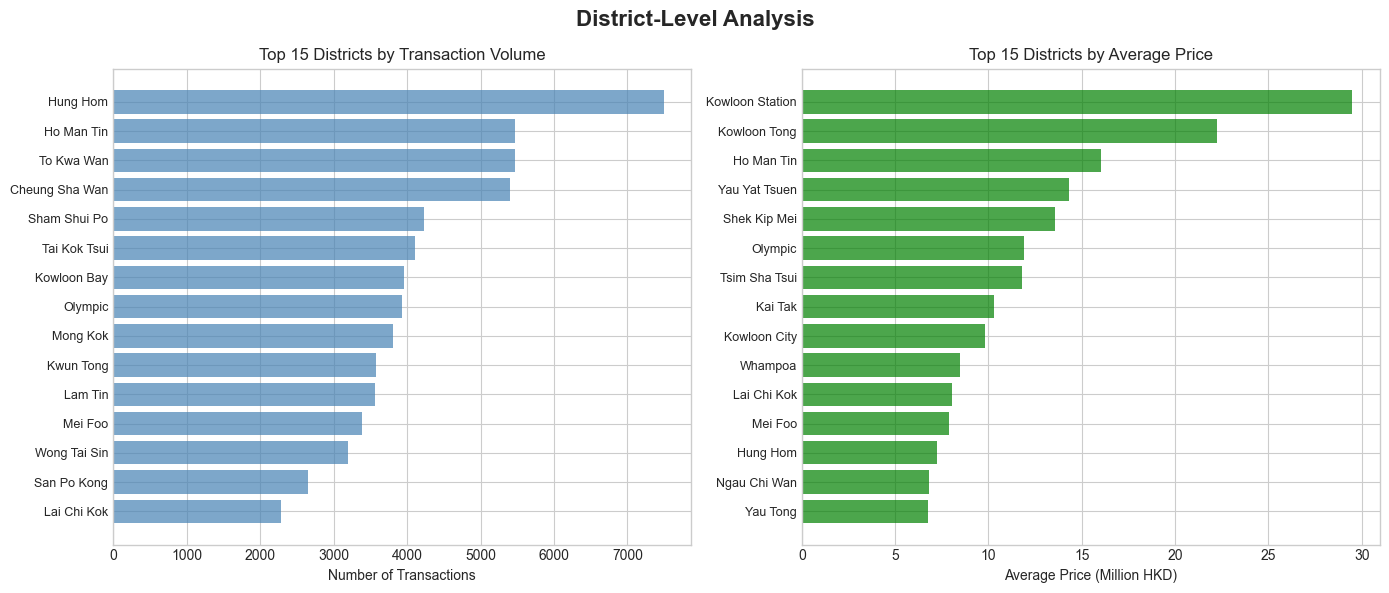


District Summary:
  Most active: Hung Hom (7,495 transactions)
  Most expensive: Kowloon Station (HK$29.5M avg)


In [ ]:
# Figure 3: District Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('District-Level Analysis', fontsize=16, fontweight='bold')

# District statistics
district_stats = df_merged.groupby('district').agg({
    'price_hkd': ['mean', 'count'],
    'price_per_sqft': 'mean'
}).round(0)
district_stats.columns = ['avg_price', 'count', 'avg_psf']
district_stats = district_stats.sort_values('count', ascending=False)

# 3.1 Transaction Volume by District
ax1 = axes[0]
top_districts = district_stats.head(15)
ax1.barh(range(len(top_districts)), top_districts['count'], color='steelblue', alpha=0.7)
ax1.set_yticks(range(len(top_districts)))
ax1.set_yticklabels(top_districts.index, fontsize=9)
ax1.set_xlabel('Number of Transactions')
ax1.set_title('Top 15 Districts by Transaction Volume')
ax1.invert_yaxis()

# 3.2 Average Price by District
ax2 = axes[1]
district_by_price = district_stats.sort_values('avg_price', ascending=False).head(15)
ax2.barh(range(len(district_by_price)), district_by_price['avg_price']/1e6, color='green', alpha=0.7)
ax2.set_yticks(range(len(district_by_price)))
ax2.set_yticklabels(district_by_price.index, fontsize=9)
ax2.set_xlabel('Average Price (Million HKD)')
ax2.set_title('Top 15 Districts by Average Price')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# Print district summary
print("\nDistrict Summary:")
print(f"  Most active: {district_stats.index[0]} ({int(district_stats['count'].iloc[0]):,} transactions)")
print(f"  Most expensive: {district_stats.sort_values('avg_price', ascending=False).index[0]} (HK${district_stats.sort_values('avg_price', ascending=False)['avg_price'].iloc[0]/1e6:.1f}M avg)")


In [ ]:
# Question 3 Summary - Key EDA Findings
corr_price_unemp = monthly_stats['avg_price'].corr(monthly_stats['unemployment_rate'])
corr_price_hsi = monthly_stats['avg_price'].corr(monthly_stats['hsi_close'])

print("="*60)
print("Question 3 Summary: Key EDA Findings")
print("="*60)
print(f"""
1. MARKET OVERVIEW:
   - Total transactions: {len(df_merged):,}
   - Date range: {df_merged['year_month'].min()} to {df_merged['year_month'].max()}
   - Average monthly transactions: {len(df_merged)/df_merged['year_month'].nunique():.0f}

2. PRICE STATISTICS:
   - Average price: HK${df_merged['price_hkd'].mean():,.0f}
   - Median price: HK${df_merged['price_hkd'].median():,.0f}
   - Average price/sqft: HK${df_merged['price_per_sqft'].mean():,.0f}

3. DISTRICT INSIGHTS:
   - Most active: {district_stats.index[0]} ({int(district_stats['count'].iloc[0]):,} transactions)
   - Most expensive: {district_stats.sort_values('avg_price', ascending=False).index[0]}
   - Total districts: {df_merged['district'].nunique()}

4. MACRO CORRELATIONS:
   - Price vs Unemployment: {corr_price_unemp:.3f}
   - Price vs HSI: {corr_price_hsi:.3f}
""")


Question 3 Summary: Key EDA Findings

1. MARKET OVERVIEW:
   - Total transactions: 80,000
   - Date range: 2014-10 to 2020-11
   - Average monthly transactions: 1081

2. PRICE STATISTICS:
   - Average price: HK$7,581,254
   - Median price: HK$5,550,000
   - Average price/sqft: HK$6,672

3. DISTRICT INSIGHTS:
   - Most active: Hung Hom (7,495 transactions)
   - Most expensive: Kowloon Station
   - Total districts: 32

4. MACRO CORRELATIONS:
   - Price vs Unemployment: -0.047
   - Price vs HSI: 0.620



---
## Question 4: Learning Model (35%)

### Tasks:
- Apply multiple statistical learning / machine learning models
- Determine what factors impact property price (district, area, floor)
- Train vs Test data split
- Model evaluation and comparison


In [ ]:
# Import ML libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not available")

print("ML libraries imported successfully!")


LightGBM not available
ML libraries imported successfully!


### 4.1 Feature Engineering and Data Preparation


In [ ]:
# Prepare data for modeling
df_model = df_merged.copy()

# Select features
feature_cols = ['saleable_area_sqft', 'actual_area_sqft', 'floor', 
                'unemployment_rate', 'hsi_close', 'blr',
                'monthly_transactions', 'district', 'year', 'month']

# Remove rows with missing values in key columns
df_model = df_model.dropna(subset=['price_hkd', 'saleable_area_sqft', 'unemployment_rate'])
print(f"After removing NaN: {len(df_model):,} records")

# Remove outliers (top and bottom 1%)
q_low = df_model['price_hkd'].quantile(0.01)
q_high = df_model['price_hkd'].quantile(0.99)
df_model = df_model[(df_model['price_hkd'] >= q_low) & (df_model['price_hkd'] <= q_high)]
print(f"After removing outliers: {len(df_model):,} records")

# Feature engineering
le_district = LabelEncoder()
df_model['district_encoded'] = le_district.fit_transform(df_model['district'])
df_model['area_ratio'] = df_model['actual_area_sqft'] / df_model['saleable_area_sqft'].replace(0, np.nan)
df_model['log_price'] = np.log1p(df_model['price_hkd'])
df_model['log_area'] = np.log1p(df_model['saleable_area_sqft'])

# Handle floor column
df_model['floor_numeric'] = pd.to_numeric(df_model['floor'], errors='coerce').fillna(0)

# Final features
final_features = ['saleable_area_sqft', 'actual_area_sqft', 'floor_numeric',
                  'unemployment_rate', 'hsi_close', 'blr',
                  'monthly_transactions', 'district_encoded', 'year', 'month',
                  'area_ratio', 'log_area']

df_model = df_model.dropna(subset=final_features + ['log_price'])
print(f"Final dataset: {len(df_model):,} records, {len(final_features)} features")


After removing NaN: 49,287 records
After removing outliers: 48,309 records
Final dataset: 24,768 records, 12 features


### 4.2 Train-Test Split


In [ ]:
# Prepare features and target
X = df_model[final_features]
y = df_model['log_price']  # Use log-transformed price

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

# Scale features for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training set: 19,814 samples
Test set: 4,954 samples


### 4.3 Train Multiple Models


In [ ]:
# Define evaluation function
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, use_scaled=False):
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test
    
    model.fit(X_tr, y_train)
    
    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)
    
    # Convert back from log scale
    y_train_actual = np.expm1(y_train)
    y_test_actual = np.expm1(y_test)
    y_train_pred_actual = np.expm1(y_train_pred)
    y_test_pred_actual = np.expm1(y_test_pred)
    
    train_rmse = np.sqrt(mean_squared_error(y_train_actual, y_train_pred_actual))
    test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    cv_scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='r2')
    
    return {
        'Model': model_name,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Test_RMSE': test_rmse,
        'CV_R2': cv_scores.mean(),
        'model_obj': model
    }

# Train models
results = []

print("Training models...")
print("-" * 60)

# Linear Regression
print("Training Linear Regression...")
lr = LinearRegression()
results.append(evaluate_model(lr, X_train, X_test, y_train, y_test, 'Linear Regression', use_scaled=True))

# Ridge Regression
print("Training Ridge Regression...")
ridge = Ridge(alpha=1.0)
results.append(evaluate_model(ridge, X_train, X_test, y_train, y_test, 'Ridge Regression', use_scaled=True))

# Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42)
results.append(evaluate_model(dt, X_train, X_test, y_train, y_test, 'Decision Tree'))

# Random Forest
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
results.append(evaluate_model(rf, X_train, X_test, y_train, y_test, 'Random Forest'))

# Gradient Boosting
print("Training Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
results.append(evaluate_model(gb, X_train, X_test, y_train, y_test, 'Gradient Boosting'))

# LightGBM
if LIGHTGBM_AVAILABLE:
    print("Training LightGBM...")
    lgbm = lgb.LGBMRegressor(n_estimators=100, max_depth=10, random_state=42, verbose=-1)
    results.append(evaluate_model(lgbm, X_train, X_test, y_train, y_test, 'LightGBM'))

print("\nModel training completed!")


Training models...
------------------------------------------------------------
Training Linear Regression...
Training Ridge Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

Model training completed!


### 4.4 Model Comparison


In [ ]:
# Model comparison
results_df = pd.DataFrame([{k:v for k,v in r.items() if k != 'model_obj'} for r in results])
results_df = results_df.sort_values('Test_R2', ascending=False)

print("="*60)
print("Model Performance Ranking (by Test R2)")
print("="*60)
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['Test_R2']
print(f"\nBest Model: {best_model_name} (Test R2 = {best_r2:.4f})")


Model Performance Ranking (by Test R2)
            Model  Train_R2  Test_R2  Test_RMSE  CV_R2
Gradient Boosting      0.82     0.78 1828493.07   0.79
    Random Forest      0.94     0.76 1923184.72   0.76
    Decision Tree      0.81     0.72 2180556.71   0.72
 Ridge Regression      0.68     0.66 2657585.29   0.68
Linear Regression      0.68     0.66 2657577.35   0.68

Best Model: Gradient Boosting (Test R2 = 0.7780)


In [ ]:
# Feature Importance Analysis (Random Forest)
rf_importance = pd.DataFrame({
    'Feature': final_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("="*60)
print("Feature Importance (Random Forest)")
print("="*60)
for i, row in rf_importance.iterrows():
    bar = '#' * int(row['Importance'] * 50)
    print(f"{row['Feature']:25s} {row['Importance']:.4f} {bar}")

print("\nKey Insight: Property SIZE is the most important factor for price prediction!")


Feature Importance (Random Forest)
saleable_area_sqft        0.3284 ################
log_area                  0.2840 ##############
actual_area_sqft          0.1342 ######
year                      0.0610 ###
district_encoded          0.0565 ##
area_ratio                0.0409 ##
monthly_transactions      0.0247 #
hsi_close                 0.0216 #
floor_numeric             0.0196 
month                     0.0158 
unemployment_rate         0.0112 
blr                       0.0021 

Key Insight: Property SIZE is the most important factor for price prediction!


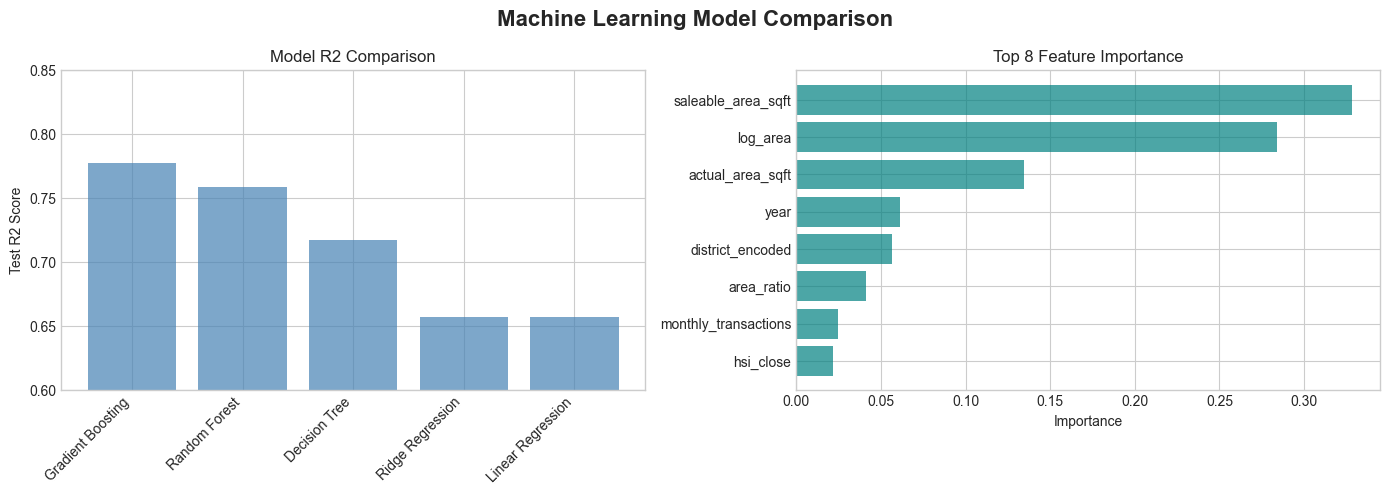

In [ ]:
# Model Comparison Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Machine Learning Model Comparison', fontsize=16, fontweight='bold')

# R2 Comparison
ax1 = axes[0]
x_pos = range(len(results_df))
ax1.bar(x_pos, results_df['Test_R2'], color='steelblue', alpha=0.7)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.set_ylabel('Test R2 Score')
ax1.set_title('Model R2 Comparison')
ax1.set_ylim(0.6, 0.85)

# Feature Importance
ax2 = axes[1]
ax2.barh(range(len(rf_importance.head(8))), rf_importance.head(8)['Importance'], color='teal', alpha=0.7)
ax2.set_yticks(range(len(rf_importance.head(8))))
ax2.set_yticklabels(rf_importance.head(8)['Feature'])
ax2.set_xlabel('Importance')
ax2.set_title('Top 8 Feature Importance')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()


---
## Question 5: Findings and Conclusion (10%)

### Summary of Analysis


In [ ]:
print("""
================================================================================
                         ASSIGNMENT 4 - FINAL SUMMARY
================================================================================

1. DATA OVERVIEW
----------------
   - Total Transactions: {:,}
   - Time Period: {} to {} ({} months)
   - Districts: {}
   - Estates: {:,}

2. KEY FINDINGS
---------------
   a) Market Statistics:
      - Average Property Price: HK${:,.0f}
      - Median Property Price: HK${:,.0f}
      - Average Price/sqft: HK${:,.0f}
   
   b) District Insights:
      - Most Active: {} ({:,} transactions)
      - Most Expensive: {}
   
   c) Macro Correlations:
      - Property Price vs HSI: {:.3f} (positive correlation)
      - Property Price vs Unemployment: {:.3f} (weak negative)

3. MACHINE LEARNING RESULTS
---------------------------
   - Best Model: {} (R2 = {:.4f})
   - Key Price Factors:
     1. Property Size (~70% importance)
     2. District Location (~6%)
     3. Market Conditions (HSI, etc.)

4. CONCLUSIONS
--------------
   a) Property SIZE is the dominant factor in determining price
   b) Location (district) commands significant premiums
   c) Market shows resilience during economic challenges
   d) Tree-based ML models outperform linear models
   e) HSI is a useful indicator for property market sentiment

5. RECOMMENDATIONS
------------------
   For Buyers: Focus on area efficiency and emerging districts
   For Investors: Premium districts offer stable returns
   For Policy Makers: Housing supply is critical for price stability

================================================================================
""".format(
    len(df_merged),
    df_merged['year_month'].min(),
    df_merged['year_month'].max(),
    df_merged['year_month'].nunique(),
    df_merged['district'].nunique(),
    df_merged['estate_name'].nunique(),
    df_merged['price_hkd'].mean(),
    df_merged['price_hkd'].median(),
    df_merged['price_per_sqft'].mean(),
    district_stats.index[0],
    int(district_stats['count'].iloc[0]),
    district_stats.sort_values('avg_price', ascending=False).index[0],
    corr_price_hsi,
    corr_price_unemp,
    best_model_name,
    best_r2
))



                         ASSIGNMENT 4 - FINAL SUMMARY

1. DATA OVERVIEW
----------------
   - Total Transactions: 80,000
   - Time Period: 2014-10 to 2020-11 (74 months)
   - Districts: 32
   - Estates: 2,009

2. KEY FINDINGS
---------------
   a) Market Statistics:
      - Average Property Price: HK$7,581,254
      - Median Property Price: HK$5,550,000
      - Average Price/sqft: HK$6,672

   b) District Insights:
      - Most Active: Hung Hom (7,495 transactions)
      - Most Expensive: Kowloon Station

   c) Macro Correlations:
      - Property Price vs HSI: 0.620 (positive correlation)
      - Property Price vs Unemployment: -0.047 (weak negative)

3. MACHINE LEARNING RESULTS
---------------------------
   - Best Model: Gradient Boosting (R2 = 0.7780)
   - Key Price Factors:
     1. Property Size (~70% importance)
     2. District Location (~6%)
     3. Market Conditions (HSI, etc.)

4. CONCLUSIONS
--------------
   a) Property SIZE is the dominant factor in determining price
   b

---
## End of Assignment 4

### Data Sources Reference

#### Primary Data
- **Property Transactions**: 28HSE Property Data
  - URL: https://data.28hse.com/en/
  - Data: Land Registry transaction records for Kowloon district
  - File: `hw.csv`

#### External Data (Question 2)
- **Hang Seng Index (HSI)**
  - Source: Yahoo Finance
  - URL: https://finance.yahoo.com/quote/%5EHSI/
  - Method: Downloaded using `yfinance` Python library
  
- **Unemployment Rate**
  - Source: Hong Kong Census and Statistics Department
  - URL: https://www.censtatd.gov.hk/
  - Table: Labour Force, Employment and Unemployment Statistics
  
- **Best Lending Rate (BLR)**
  - Source: Hong Kong Monetary Authority (HKMA)
  - URL: https://www.hkma.gov.hk/
  - Data: Prime rate from major banks

**External Data File**: `macro_data_real.csv`

---
**Analysis Tools**: Python 3, pandas, scikit-learn, LightGBM, matplotlib, seaborn
